In [ ]:
import pandas as pd
from pathlib import Path
import pickle

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from scipy.stats import randint, uniform

# load train data
X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()


In [6]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    "clf__C": [0.01, 0.1, 1, 10],
    "clf__solver": ["lbfgs", "liblinear"],
    "clf__penalty": ["l2"],
}

grid_lr = GridSearchCV(
    lr_pipe,
    param_grid=param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
)

grid_lr.fit(X_train, y_train)
best_lr = grid_lr.best_estimator_
print("Best LR params:", grid_lr.best_params_)
print("Best LR F1 (cv):", grid_lr.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best LR params: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best LR F1 (cv): 0.7621827969251067


In [7]:
dt = DecisionTreeClassifier(random_state=42)

param_dist_dt = {
    "max_depth": randint(2, 30),
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 20),
}

rand_dt = RandomizedSearchCV(
    dt,
    param_distributions=param_dist_dt,
    n_iter=40,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

rand_dt.fit(X_train, y_train)
best_dt = rand_dt.best_estimator_
print("Best DT params:", rand_dt.best_params_)
print("Best DT F1 (cv):", rand_dt.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best DT params: {'max_depth': 12, 'min_samples_leaf': 4, 'min_samples_split': 9}
Best DT F1 (cv): 0.8231882864510025


In [12]:

rf = RandomForestClassifier(random_state=42, n_estimators=200)

param_dist_rf = {
    "n_estimators": randint(100, 400),
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2", None],
}

rand_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=40,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

rand_rf.fit(X_train, y_train)
best_rf = rand_rf.best_estimator_
print("Best RF params:", rand_rf.best_params_)
print("Best RF F1 (cv):", rand_rf.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best RF params: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 330}
Best RF F1 (cv): 0.8446420622055577


In [13]:

xgb_clf = xgb.XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

param_dist_xgb = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.3),
    "subsample": uniform(0.6, 0.4),       # 0.6–1.0
    "colsample_bytree": uniform(0.6, 0.4),
}

rand_xgb = RandomizedSearchCV(
    xgb_clf,
    param_distributions=param_dist_xgb,
    n_iter=40,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

rand_xgb.fit(X_train, y_train)
best_xgb = rand_xgb.best_estimator_
print("Best XGB params:", rand_xgb.best_params_)
print("Best XGB F1 (cv):", rand_xgb.best_score_)

c:\Users\bhara\.conda\envs\creditRisk\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
c:\Users\bhara\.conda\envs\creditRisk\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
c:\Users\bhara\.conda\envs\creditRisk\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB params: {'colsample_bytree': 0.7123738038749523, 'learning_rate': 0.17280882494747454, 'max_depth': 3, 'n_estimators': 256, 'subsample': 0.9208787923016158}
Best XGB F1 (cv): 0.8676857691911083


In [14]:
models_dir = Path("..") / "models"
models_dir.mkdir(parents=True, exist_ok=True)

with open(models_dir / "logistic_regression_tuned.pkl", "wb") as f:
    pickle.dump(best_lr, f)

with open(models_dir / "decision_tree_tuned.pkl", "wb") as f:
    pickle.dump(best_dt, f)

with open(models_dir / "random_forest_tuned.pkl", "wb") as f:
    pickle.dump(best_rf, f)

with open(models_dir / "xgboost_tuned.pkl", "wb") as f:
    pickle.dump(best_xgb, f)

print("Saved tuned models to:", models_dir.resolve())

Saved tuned models to: D:\projects\credit-risk-ml-pipeline\models


In [17]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()  # parent of 'notebooks'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.feature_engineering import evaluate_model

In [18]:
from src.feature_engineering import evaluate_model
import pandas as pd
import pickle
from pathlib import Path

from src.feature_engineering import evaluate_model

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()


In [19]:
y_pred_lr = best_lr.predict(X_test)
y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

y_pred_dt = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

y_pred_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

In [20]:
results_tuned = {
    "Logistic Regression (tuned)": evaluate_model(y_test, y_pred_lr, y_proba_lr),
    "Decision Tree (tuned)": evaluate_model(y_test, y_pred_dt, y_proba_dt),
    "Random Forest (tuned)": evaluate_model(y_test, y_pred_rf, y_proba_rf),
    "XGBoost (tuned)": evaluate_model(y_test, y_pred_xgb, y_proba_xgb),
}

comparison_tuned_df = pd.DataFrame(results_tuned).T
comparison_tuned_df

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression (tuned),0.8535,0.795252,0.775687,0.785348,0.924106
Decision Tree (tuned),0.8780,0.829161,0.814761,0.821898,0.933422
Random Forest (tuned),0.8925,0.843931,0.845152,0.844541,0.957690
XGBoost (tuned),0.9010,0.854676,0.859624,0.857143,0.975586


<Figure size 1000x600 with 0 Axes>

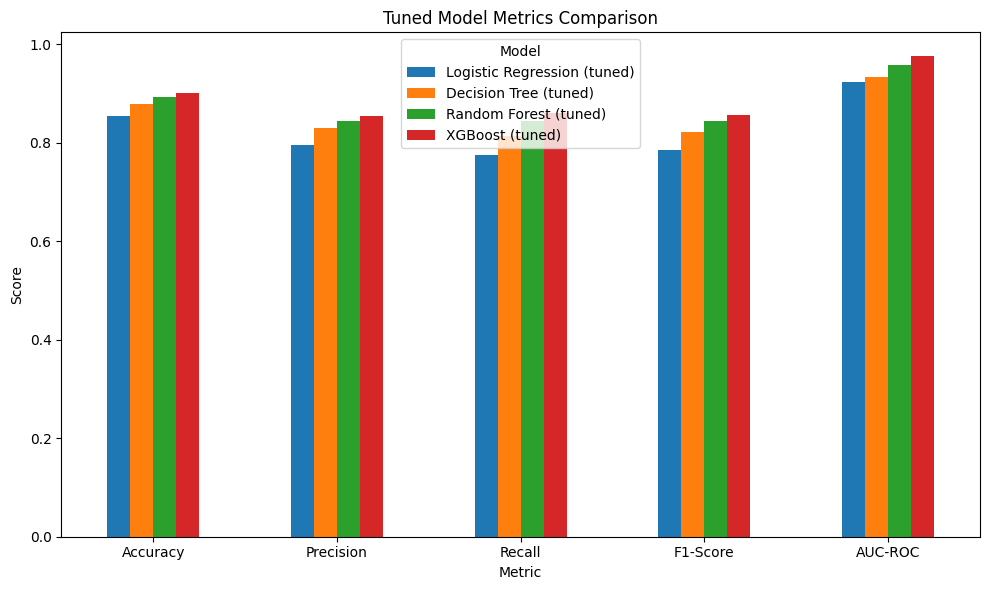

In [21]:
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure metric order
metrics_order = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
plot_df = comparison_tuned_df[metrics_order].T   # rows = metrics, columns = models

plt.figure(figsize=(10, 6))
plot_df.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Tuned Model Metrics Comparison")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()

# Optional: save to reports/figures
figures_dir = Path("..") / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "tuned_model_metric_comparison.png", dpi=300, bbox_inches="tight")

plt.show()